In [54]:
import matplotlib.pyplot as plt
import numpy as np 
import torch
import pickle
import pandas as pd

In [55]:
def get_quantile(samples,q,dim=1):
    return torch.quantile(samples,q,dim=dim).cpu().numpy()

In [68]:
dataset = 'airquality' #choose 'healthcare' or 'airquality'
datafolder_base = 'pm_validation/run4'
datafolder_dps = 'pm25/hf/window=left+right/pm25,w_b=5,h=0.1,d=4/run4'
#datafolder = 'pretrained' # set the folder name
nsample = 100 # number of generated sample


# ---- ① baseline 결과 읽기 ----
path_base = f'../save/{datafolder_base}/generated_outputs_nsample{nsample}.pk'
with open(path_base, 'rb') as f:
    samples_base, all_target, all_evalpoint, all_observed, all_observed_time, scaler, mean_scaler = pickle.load(f)

# ---- ② DPS 결과 읽기 ----
path_dps = f'save/{datafolder_dps}/generated_outputs_nsample{nsample}.pk'
with open(path_dps, 'rb') as f:
    samples_dps, _, _, _, _, _, _ = pickle.load(f)

#path = './save/'+datafolder+'/generated_outputs_nsample' + str(nsample) + '.pk' 
#with open(path, 'rb') as f:
#    samples,all_target,all_evalpoint,all_observed,all_observed_time,scaler,mean_scaler = pickle.load( f)

all_target_np = all_target.cpu().numpy()
all_evalpoint_np = all_evalpoint.cpu().numpy()
all_observed_np = all_observed.cpu().numpy()
all_given_np = all_observed_np - all_evalpoint_np

K = samples_base.shape[-1]
L = samples_base.shape[-2]

if dataset == 'airquality':
    path = 'data/pm25/pm25_meanstd.pk'
    with open(path, 'rb') as f:
        train_mean,train_std = pickle.load(f)
    train_std_t  = torch.from_numpy(train_std).to(samples_base.device)
    train_mean_t = torch.from_numpy(train_mean).to(samples_base.device)
    all_target_np = (all_target_np * train_std + train_mean)
    samples_base  = (samples_base * train_std_t + train_mean_t)
    samples_dps   = (samples_dps  * train_std_t + train_mean_t)

In [69]:

qlist = [0.05, 0.25, 0.5, 0.75, 0.95]

quantiles_base = []
quantiles_dps  = []

for q in qlist:
    q_base = get_quantile(samples_base, q, dim=1)*(1 - all_given_np) + all_target_np*all_given_np
    q_dps  = get_quantile(samples_dps,  q, dim=1)*(1 - all_given_np) + all_target_np*all_given_np

    quantiles_base.append(q_base)
    quantiles_dps.append(q_dps)

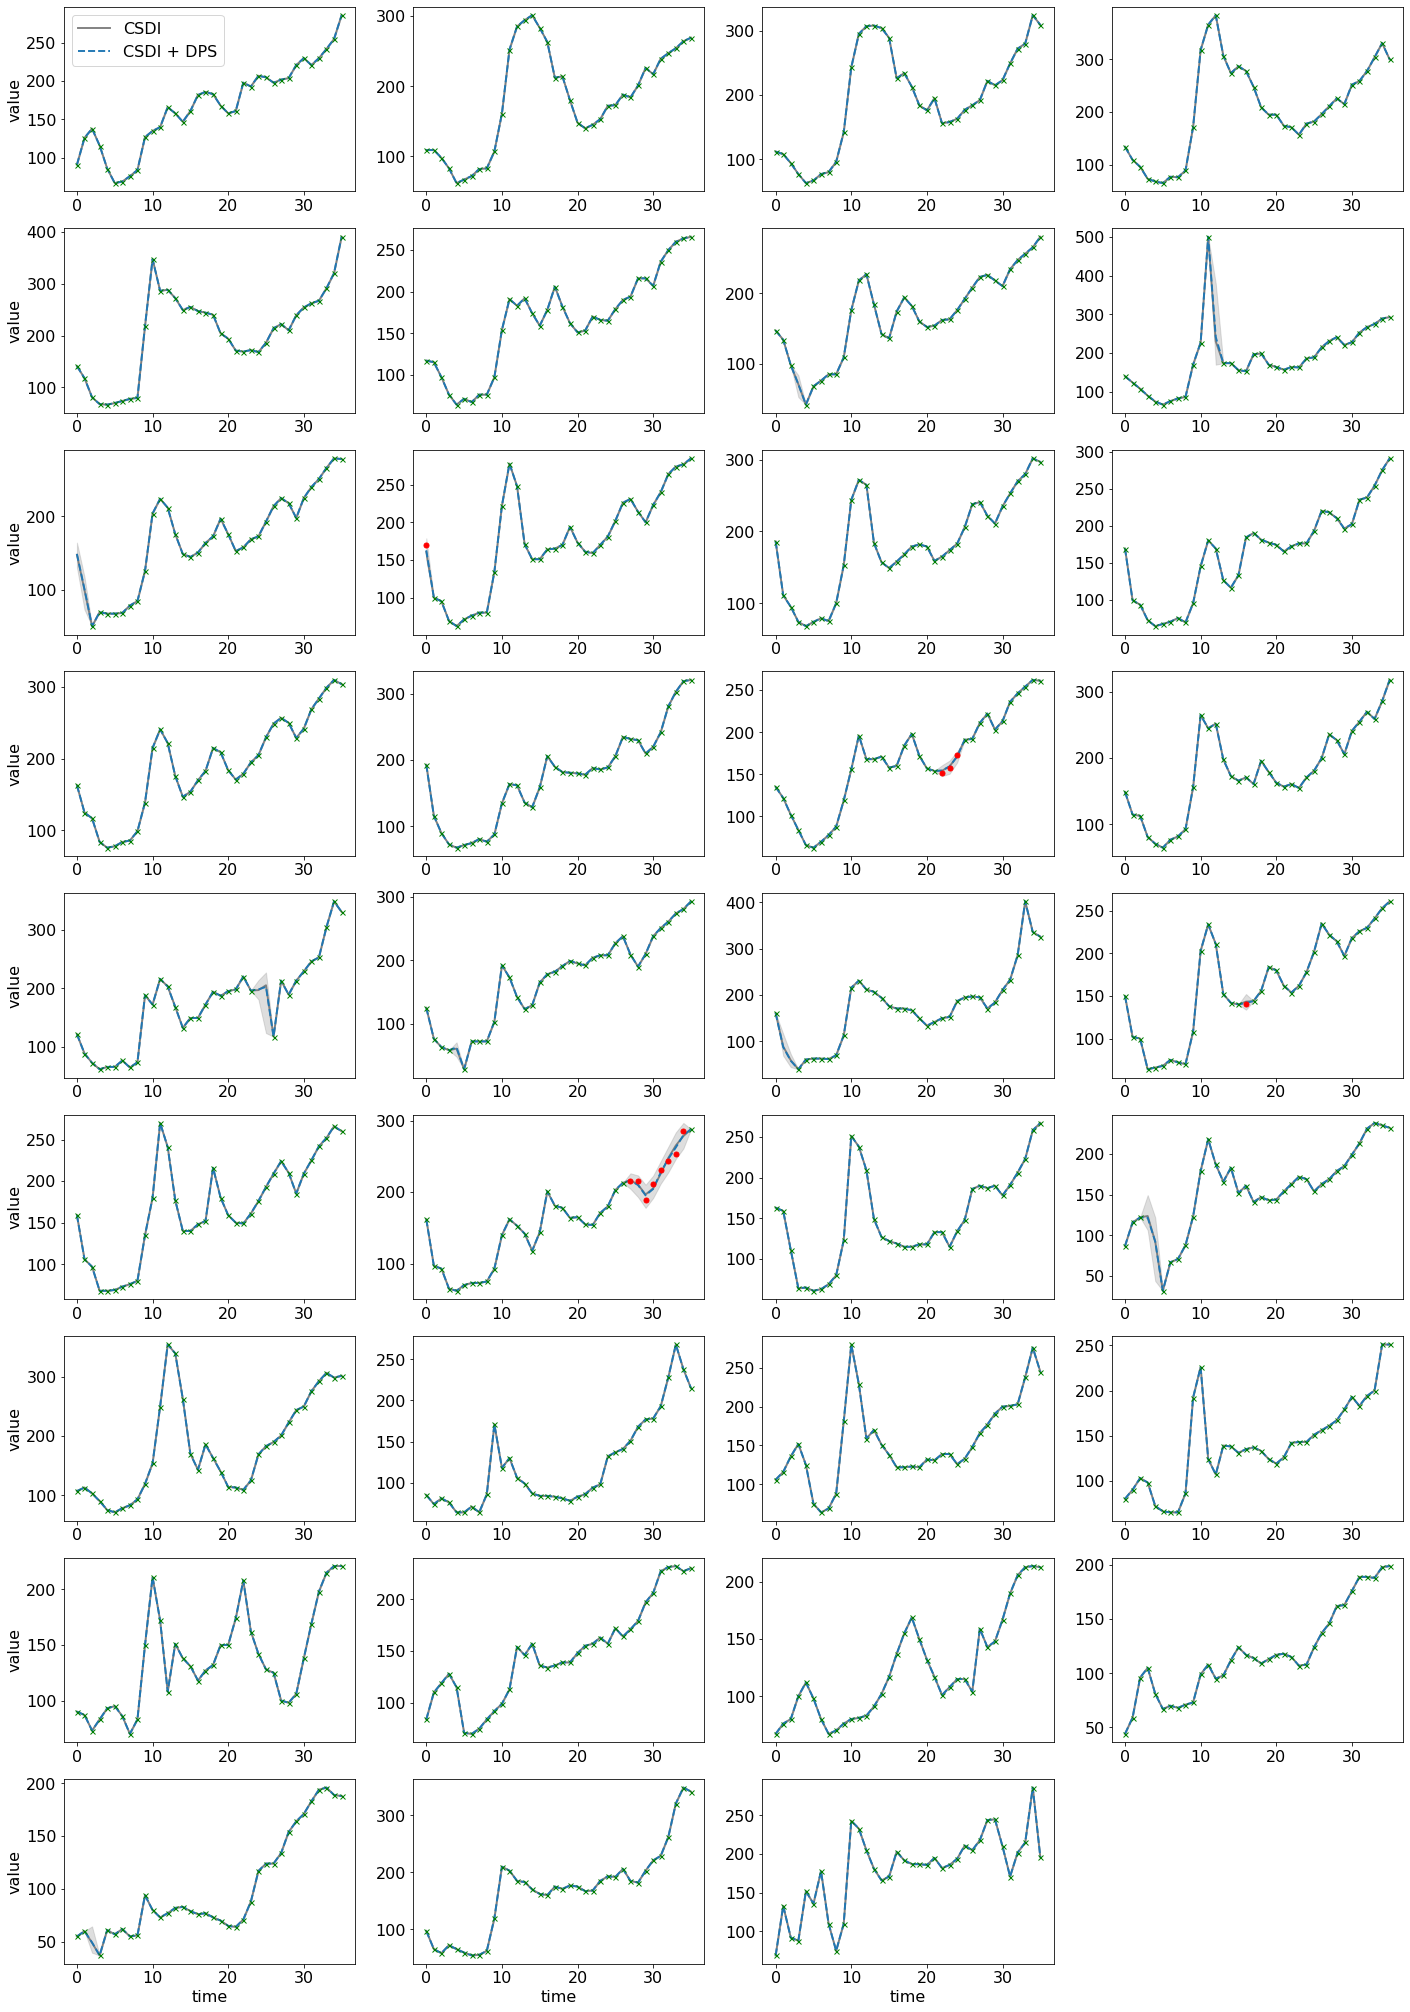

Time Length (L): 36, Feature Count (K): 36


In [14]:
###healthcare###
dataind = 3 #change to visualize a different time-series sample

plt.rcParams["font.size"] = 16
fig, axes = plt.subplots(nrows=9, ncols=4,figsize=(24.0, 36.0))
fig.delaxes(axes[-1][-1])

for k in range(K):
    df = pd.DataFrame({"x":np.arange(0,L), "val":all_target_np[dataind,:,k], "y":all_evalpoint_np[dataind,:,k]})
    df = df[df.y != 0]
    df2 = pd.DataFrame({"x":np.arange(0,L), "val":all_target_np[dataind,:,k], "y":all_given_np[dataind,:,k]})
    df2 = df2[df2.y != 0]
    row = k // 4
    col = k % 4
    # ----- CSDI baseline: line only -----
    axes[row][col].plot(
    range(L),
    quantiles_base[2][dataind, :, k],
    color='tab:gray',
    linestyle='-',
    linewidth=1.9,
    label='CSDI')
    # ----- DPS: line + band -----
    axes[row][col].plot(
    range(L),
    quantiles_dps[2][dataind, :, k],
    color='tab:blue',
    linestyle='--',
    linewidth=1.9,
    label='CSDI + DPS')
    axes[row][col].fill_between(
    range(L),
    quantiles_dps[0][dataind, :, k],
    quantiles_dps[4][dataind, :, k],
    color='tab:gray',
    alpha=0.25)
    # ----- points -----
    axes[row][col].plot(df.x,  df.val,  marker='o', color='red',   linestyle='None', markersize=5)   # eval
    axes[row][col].plot(df2.x, df2.val, marker='x', color='green', linestyle='None', markersize=5)  # given


    if col == 0:
        axes[row][col].set_ylabel('value')
    if row == 8:
        axes[row][col].set_xlabel('time')
axes[0][0].legend()
    
    
fig.savefig('./save/pm25_validation0_csdi_vs_dps.png',dpi=300, bbox_inches='tight')
plt.show()
print(f"Time Length (L): {L}, Feature Count (K): {K}")
# 정상 결과: Time Length: 48, Feature Count: 35

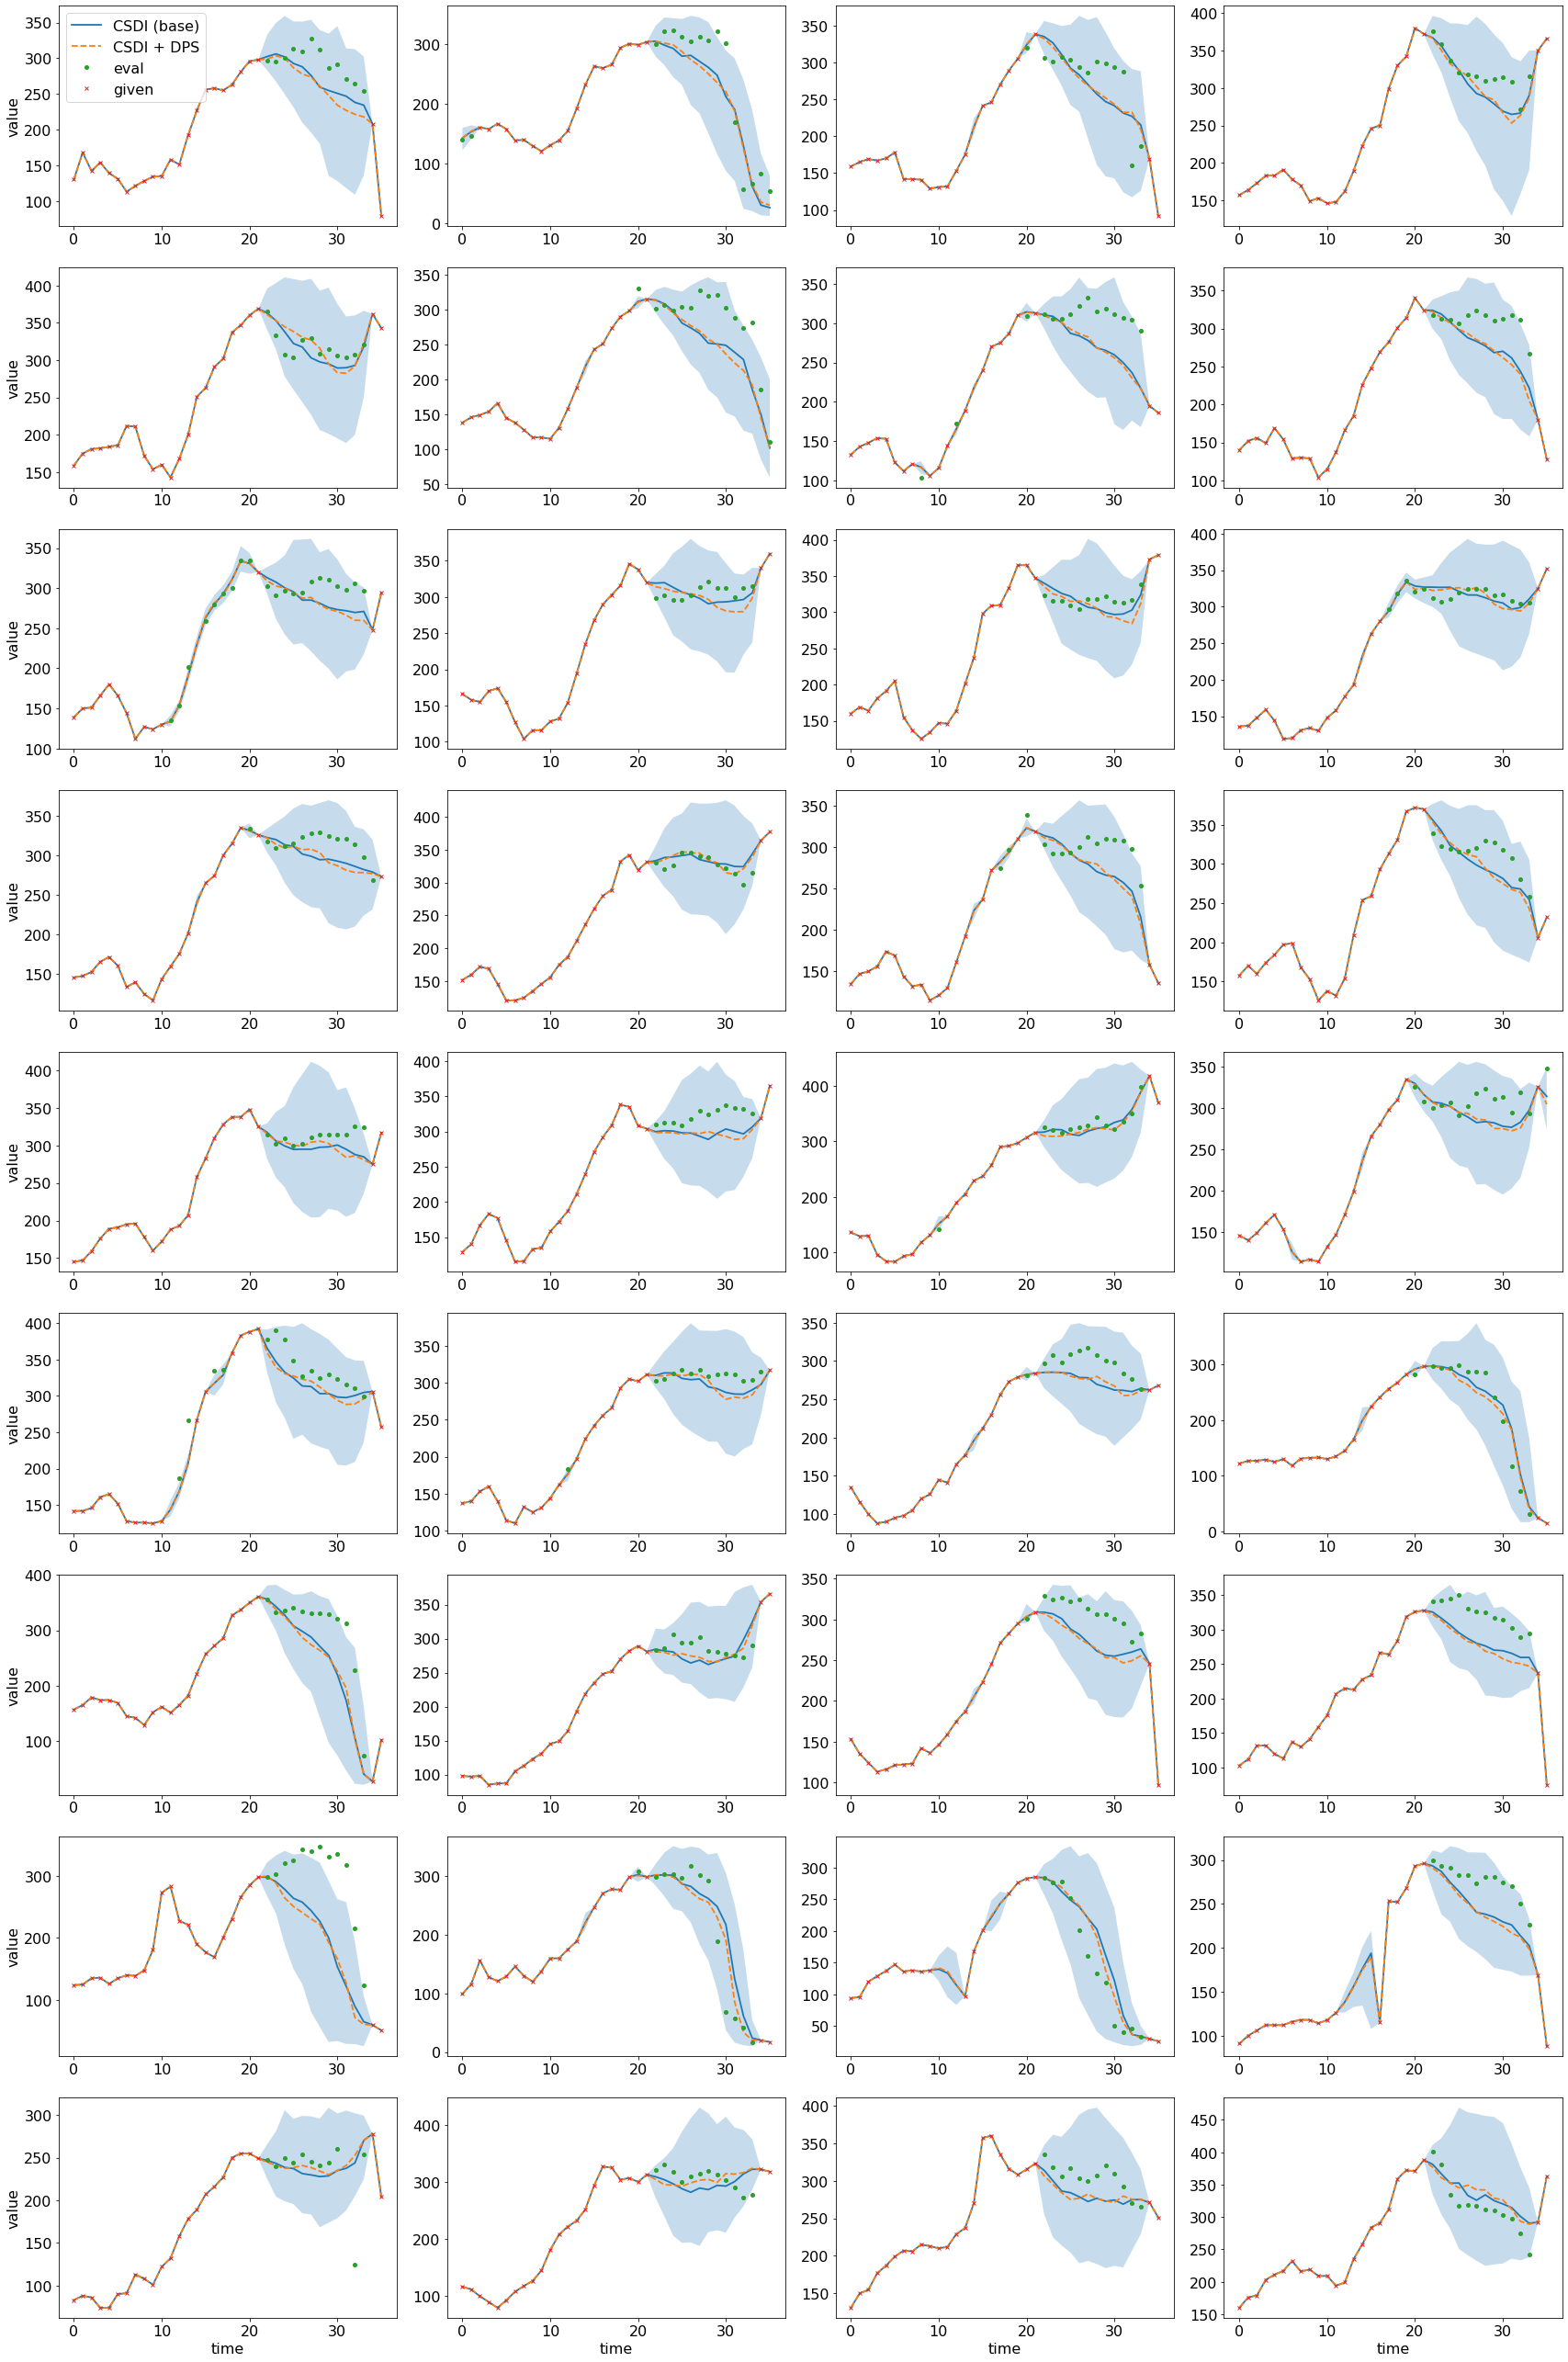

Saved: ./save/pm25_validation4_csdi_vs_dps.png
Time Length (L): 36, Feature Count (K): 36


In [70]:
# === PM2.5 (airquality) visualize: baseline vs DPS ===
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

dataind = 10  

plt.rcParams["font.size"] = 16

ncols = 4
nrows = math.ceil(K / ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(24.0, 4.0 * nrows))

# axes를 2D로 맞추기
if nrows == 1:
    axes = np.expand_dims(axes, axis=0)

# K보다 많은 빈 축 삭제
for idx in range(K, nrows * ncols):
    r, c = divmod(idx, ncols)
    fig.delaxes(axes[r][c])

for k in range(K):
    row, col = divmod(k, ncols)

    # eval point (파란 점용) / given point (빨간 x용)
    df_eval = pd.DataFrame({
        "x": np.arange(L),
        "val": all_target_np[dataind, :, k],
        "y": all_evalpoint_np[dataind, :, k]
    })
    df_eval = df_eval[df_eval.y != 0]

    df_given = pd.DataFrame({
        "x": np.arange(L),
        "val": all_target_np[dataind, :, k],
        "y": all_given_np[dataind, :, k]
    })
    df_given = df_given[df_given.y != 0]

    ax = axes[row][col]

    # baseline (median)
    ax.plot(
        range(L),
        quantiles_base[2][dataind, :, k],
        linestyle='-',
        linewidth=1.8,
        label='CSDI (base)'
    )

    # dps (median + band)
    ax.plot(
        range(L),
        quantiles_dps[2][dataind, :, k],
        linestyle='--',
        linewidth=1.8,
        label='CSDI + DPS'
    )
    ax.fill_between(
        range(L),
        quantiles_dps[0][dataind, :, k],
        quantiles_dps[4][dataind, :, k],
        alpha=0.25
    )

    # points
    ax.plot(df_eval.x, df_eval.val, marker='o', linestyle='None', markersize=4, label='eval' if k == 0 else None)
    ax.plot(df_given.x, df_given.val, marker='x', linestyle='None', markersize=4, label='given' if k == 0 else None)

    if col == 0:
        ax.set_ylabel("value")
    if row == nrows - 1:
        ax.set_xlabel("time")

axes[0][0].legend()
fig.tight_layout()

out_path = f'./save/pm25_validation4_csdi_vs_dps.png'
fig.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

print("Saved:", out_path)
print(f"Time Length (L): {L}, Feature Count (K): {K}")